# 📘 Análisis del Rendimiento Estudiantil  
## 🎯 Definición del Problema

> **¿Cómo afectan los hábitos de vida** (`Sleep_Hours`, `Physical_Activity`, `Extracurricular_Activities`) **y los hábitos de estudio** (`Hours_Studied`, `Tutoring_Sessions`) **al** `Exam_Score`?

---

### 🧩 Variables clave a analizar
- **Hábitos de vida:** `Sleep_Hours`, `Physical_Activity`, `Extracurricular_Activities`  
- **Hábitos de estudio:** `Hours_Studied`, `Tutoring_Sessions`  
- **Variable objetivo:** `Exam_Score`

## 📚 Diccionario de Datos

| # | Variable | Tipo | Descripción |
|---|----------|------|-------------|
| 1 | `Hours_Studied` | Numérica | Horas de estudio por semana |
| 2 | `Attendance` | Numérica | Porcentaje de asistencia a clases |
| 3 | `Parental_Involvement` | Categórica | Nivel de involucramiento de los padres (`Low`, `Medium`, `High`) |
| 4 | `Access_to_Resources` | Categórica | Acceso a recursos educativos (`Low`, `Medium`, `High`) |
| 5 | `Extracurricular_Activities` | Categórica | Participación en actividades extracurriculares (`Yes`, `No`) |
| 6 | `Sleep_Hours` | Numérica | Promedio de horas de sueño por noche |
| 7 | `Previous_Scores` | Numérica | Puntaje obtenido en exámenes anteriores |
| 8 | `Motivation_Level` | Categórica | Nivel de motivación del estudiante (`Low`, `Medium`, `High`) |
| 9 | `Internet_Access` | Categórica | Acceso a internet (`Yes`, `No`) |
| 10 | `Tutoring_Sessions` | Numérica | Número de sesiones de tutoría por mes |
| 11 | `Family_Income` | Categórica | Nivel de ingresos familiares (`Low`, `Medium`, `High`) |
| 12 | `Teacher_Quality` | Categórica | Calidad del docente (`Low`, `Medium`, `High`) |
| 13 | `School_Type` | Categórica | Tipo de institución educativa (`Public`, `Private`) |
| 14 | `Peer_Influence` | Categórica | Influencia del entorno social (`Positive`, `Neutral`, `Negative`) |
| 15 | `Physical_Activity` | Numérica | Horas de actividad física por semana |
| 16 | `Learning_Disabilities` | Categórica | Presencia de discapacidades de aprendizaje (`Yes`, `No`) |
| 17 | `Parental_Education_Level` | Categórica | Nivel educativo de los padres (`High School`, `College`, `Postgraduate`) |
| 18 | `Distance_from_Home` | Categórica | Distancia del hogar a la escuela (`Near`, `Moderate`, `Far`) |
| 19 | `Gender` | Categórica | Género del estudiante (`Male`, `Female`) |
| 20 | `Exam_Score` | Numérica | 🎯 **Variable objetivo** — Puntaje obtenido en el examen final |

In [19]:
# importar librerías
import kagglehub
import pandas as pd
import os
import shutil
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import f_oneway, kruskal

In [20]:

path = kagglehub.dataset_download("grandmaster07/student-exam-performance-dataset-analysis")

In [21]:

# Ver archivos descargados
if not os.path.exists(path):
    raise FileNotFoundError(f"No existe la ruta descargada: {path}")

archivos = os.listdir(path)
print("Archivos en la descarga:", archivos)

# Buscar automáticamente el primer CSV
csv_files = [f for f in archivos if f.lower().endswith(".csv")]

if not csv_files:
    raise FileNotFoundError("No se encontró ningún archivo CSV en la carpeta descargada.")

archivo_origen = os.path.join(path, csv_files[0])
destino_dir = "../data/student_performance"
archivo_destino = os.path.join(destino_dir, "student_performance.csv")

# Crear carpeta destino si no existe
os.makedirs(destino_dir, exist_ok=True)

# Copiar solo si no existe
if os.path.exists(archivo_destino):
    print(f"El archivo ya existe: {archivo_destino}")
else:
    shutil.copy2(archivo_origen, archivo_destino)
    print(f"Archivo copiado correctamente a: {archivo_destino}")

Archivos en la descarga: ['StudentPerformanceFactors.csv']
El archivo ya existe: ../data/student_performance/student_performance.csv


In [22]:
df = pd.read_csv("../data/student_performance/student_performance.csv")
df.head()


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [23]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

In [24]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


## Sección Limpieza de Datos




### <span style="color:red;">  Manejo de nulos</span>.

In [25]:
# Imprimir columnas con nulos
print("Columnas con valores nulos:")
print(df.isnull().sum())

# Porcentaje de nulos por columna (solo columnas con nulos)
columnas_con_nulos = df.columns[df.isnull().any()].tolist()
null_percentage = df[columnas_con_nulos].isnull().sum() / len(df) * 100

print("="*50)
print("Porcentaje de valores nulos en cada columna:")
print(null_percentage)

Columnas con valores nulos:
Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64
Porcentaje de valores nulos en cada columna:
Teacher_Quality             1.180566
Parental_Education_Level    1.362192
Distance_from_Home          1.014076
dtype: float64


al ser tan pocos decidiremos borrar los faltantes

In [26]:
# eliminar filas con nulos
print("Antes de eliminar filas con nulos:", df.shape[0])
df = df.dropna()
print("Después de eliminar filas con nulos:", df.shape[0])



Antes de eliminar filas con nulos: 6607
Después de eliminar filas con nulos: 6378



### <span style="color:red;"> Tipos de datos</span>.


In [27]:
print(df.dtypes)

Hours_Studied                 int64
Attendance                    int64
Parental_Involvement            str
Access_to_Resources             str
Extracurricular_Activities      str
Sleep_Hours                   int64
Previous_Scores               int64
Motivation_Level                str
Internet_Access                 str
Tutoring_Sessions             int64
Family_Income                   str
Teacher_Quality                 str
School_Type                     str
Peer_Influence                  str
Physical_Activity             int64
Learning_Disabilities           str
Parental_Education_Level        str
Distance_from_Home              str
Gender                          str
Exam_Score                    int64
dtype: object


### <span style="color:red;"> Estandarizar categoricas </span>.


In [28]:
print("Valores únicos en columnas categóricas:")
for col in df.select_dtypes(include=["object", "string"]).columns:
    print("="*50)   
    print(f"{col}: {df[col].unique()}")


Valores únicos en columnas categóricas:
Parental_Involvement: <StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str
Access_to_Resources: <StringArray>
['High', 'Medium', 'Low']
Length: 3, dtype: str
Extracurricular_Activities: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Motivation_Level: <StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str
Internet_Access: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Family_Income: <StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str
Teacher_Quality: <StringArray>
['Medium', 'High', 'Low']
Length: 3, dtype: str
School_Type: <StringArray>
['Public', 'Private']
Length: 2, dtype: str
Peer_Influence: <StringArray>
['Positive', 'Negative', 'Neutral']
Length: 3, dtype: str
Learning_Disabilities: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Parental_Education_Level: <StringArray>
['High School', 'College', 'Postgraduate']
Length: 3, dtype: str
Distance_from_Home: <StringArray>
['Near', 'Moderate', 'Far']
Length: 3, dt

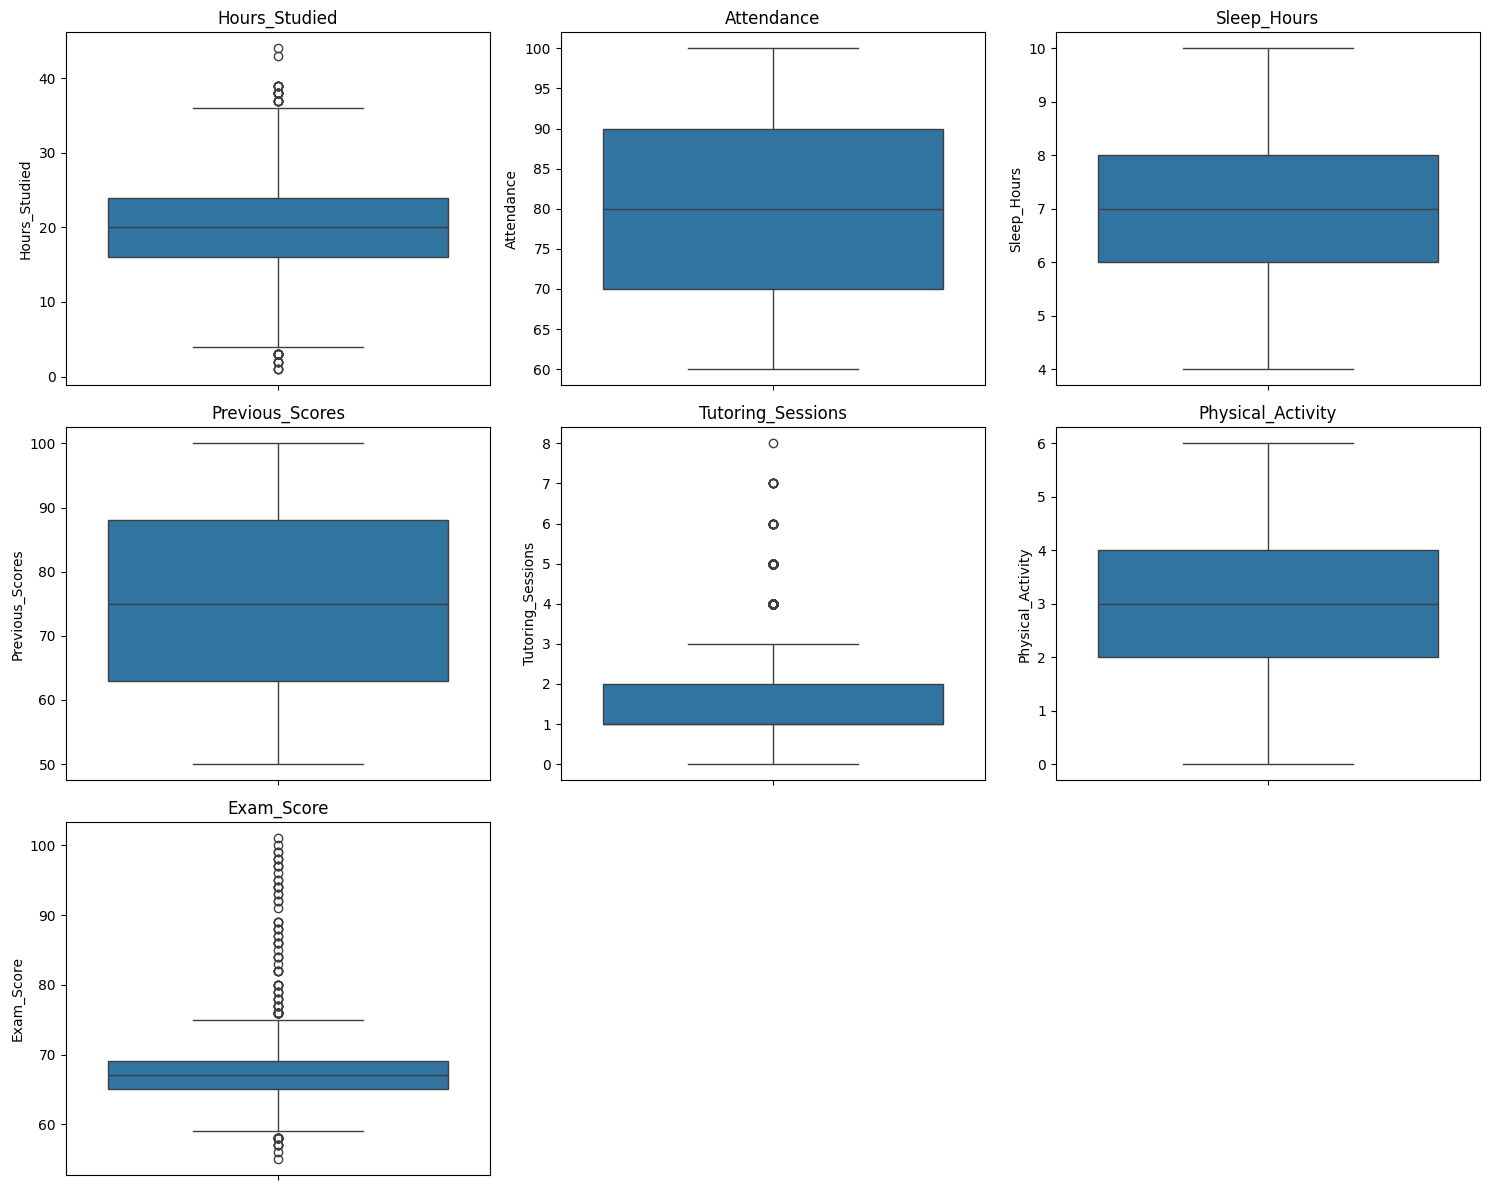

In [29]:
# Lista de columnas numéricas
numericas = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 
             'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']

# Configurar subplots
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.ravel()  # aplanar para iterar fácil

for i, col in enumerate(numericas):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

# Eliminar ejes vacíos (si hay menos de 9 gráficos)
for j in range(len(numericas), 9):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [30]:
# Función para detectar outliers usando IQR
def detectar_outliers_iqr(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    outliers = df[(df[columna] < limite_inferior) | (df[columna] > limite_superior)]
    return outliers, limite_inferior, limite_superior

# Aplicar a cada columna numérica
for col in numericas:
    outliers, lim_inf, lim_sup = detectar_outliers_iqr(df, col)
    print(f"{col}: {len(outliers)} outliers detectados")
    print(f"  Límites: [{lim_inf:.2f}, {lim_sup:.2f}]")
    if len(outliers) > 0:
        print(f"  Valores extremos: {outliers[col].tolist()[:5]}...")  # primeros 5
    print("-" * 40)

Hours_Studied: 40 outliers detectados
  Límites: [4.00, 36.00]
  Valores extremos: [43, 1, 38, 3, 3]...
----------------------------------------
Attendance: 0 outliers detectados
  Límites: [40.00, 120.00]
----------------------------------------
Sleep_Hours: 0 outliers detectados
  Límites: [3.00, 11.00]
----------------------------------------
Previous_Scores: 0 outliers detectados
  Límites: [25.50, 125.50]
----------------------------------------
Tutoring_Sessions: 423 outliers detectados
  Límites: [-0.50, 3.50]
  Valores extremos: [4, 4, 5, 4, 4]...
----------------------------------------
Physical_Activity: 0 outliers detectados
  Límites: [-1.00, 7.00]
----------------------------------------
Exam_Score: 103 outliers detectados
  Límites: [59.00, 75.00]
  Valores extremos: [100, 76, 79, 78, 89]...
----------------------------------------


### Acciones para los outliers
Las Hours_Studied las matendremos todos, 43 horas son muchas pero puede ser un estudiante muy dedicado y una hora puede ser uno no tan bueno
Tutoring_Sessions

## 🔍 Exploración de Datos (EDA)  
### ✨ Descubriendo patrones en el rendimiento estudiantil

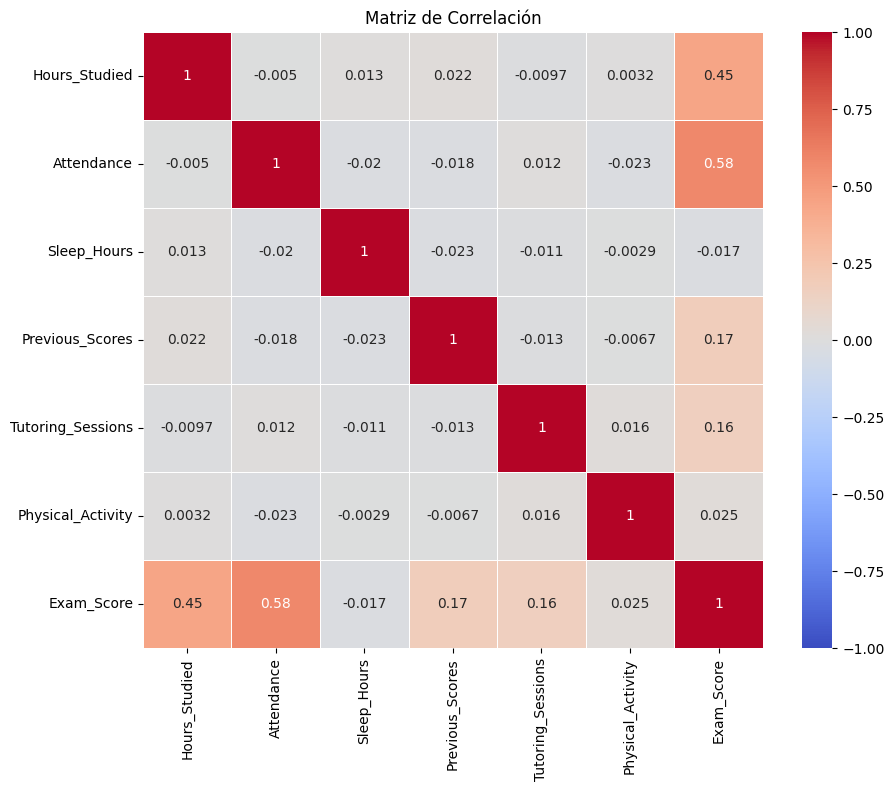

In [31]:
# Matriz de correlacion
plt.figure(figsize=(10, 8))
sns.heatmap(df[numericas].corr(), annot=True, cmap="coolwarm",
            vmin=-1, vmax=1, linewidths=0.5)
plt.title("Matriz de Correlación")
plt.show()

correlación se observa que las variables con mayor relación positiva con el puntaje del examen son **Attendance** (\(r = 0.58\)) y **Hours_Studied** (\(r = 0.48\)).

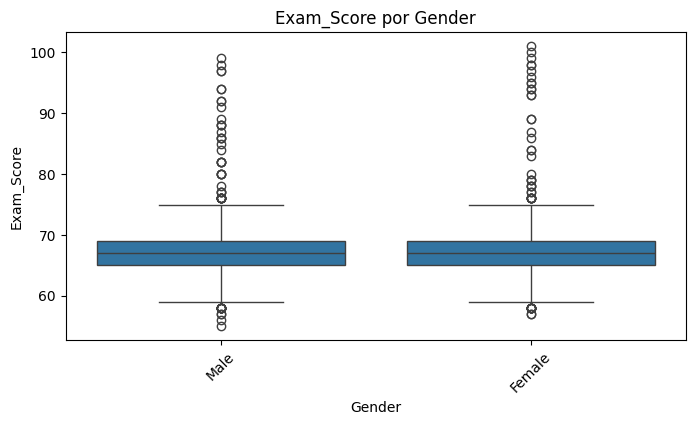

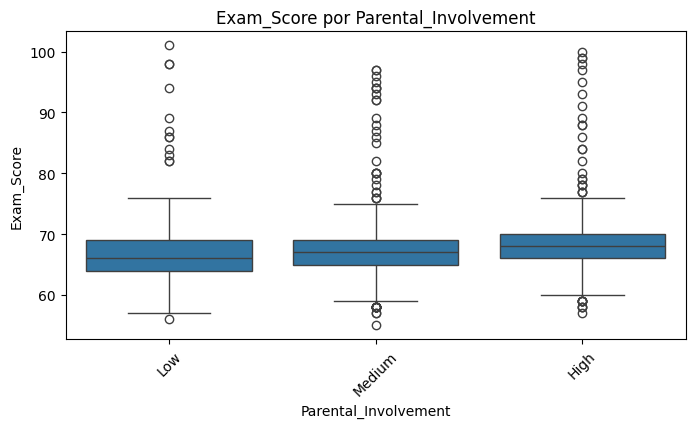

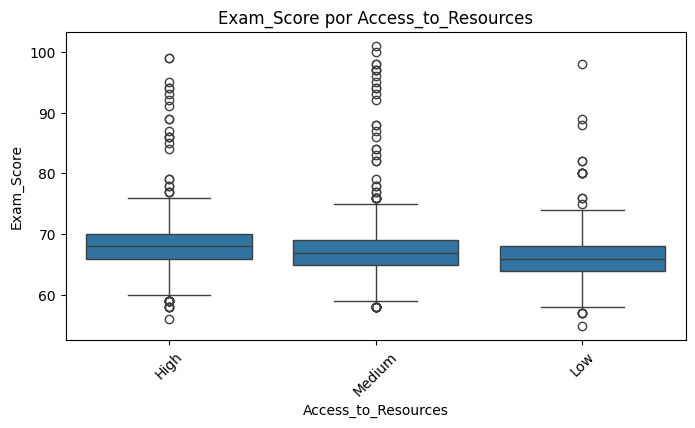

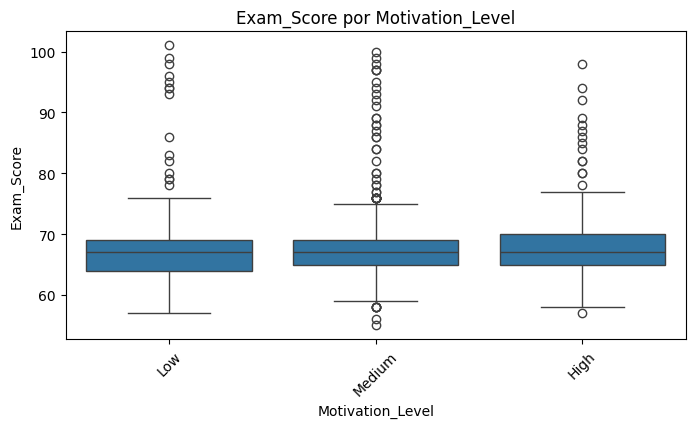

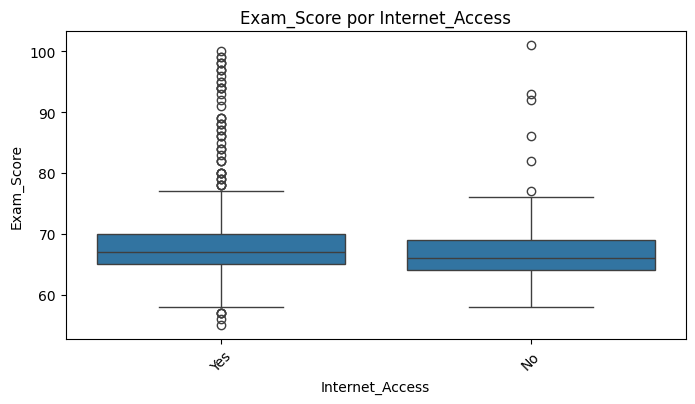

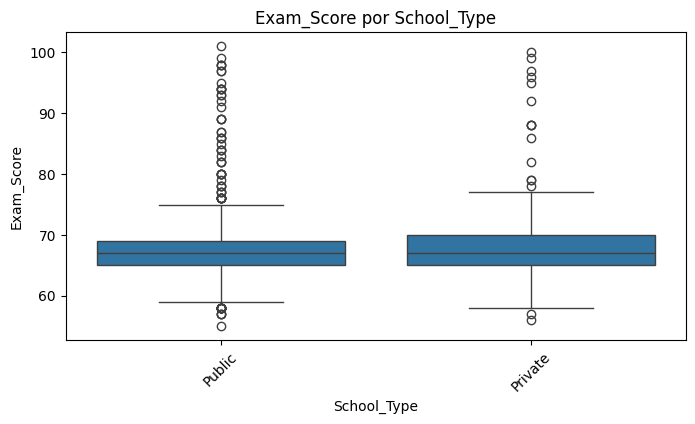

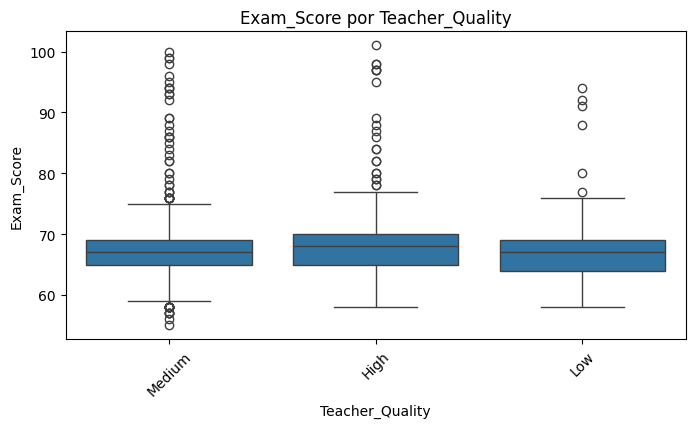

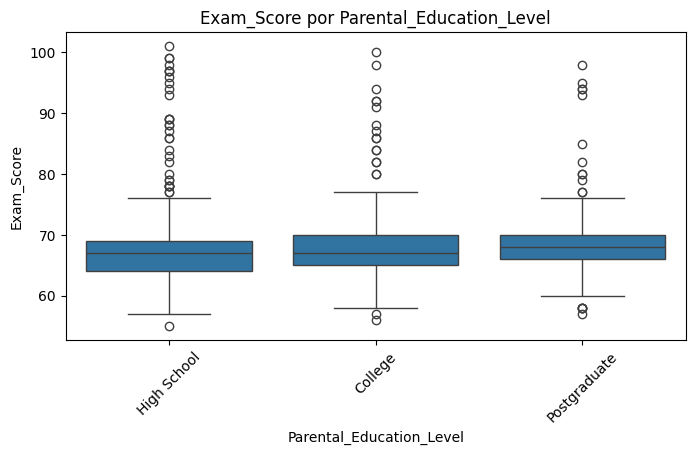

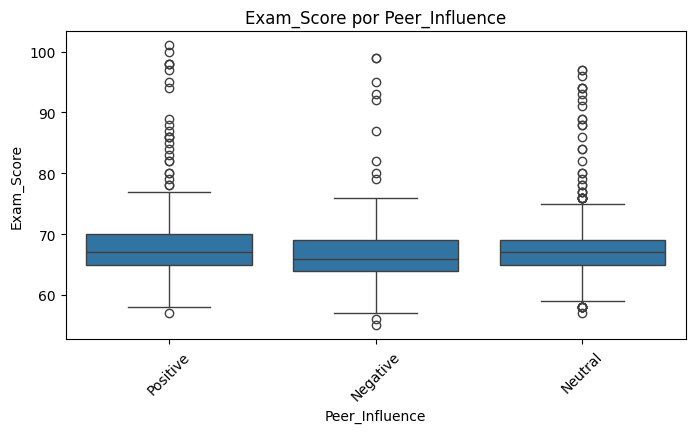

In [32]:
# Lista de categóricas relevantes (puedes ajustar)
categoricals = ['Gender', 'Parental_Involvement', 'Access_to_Resources', 
                'Motivation_Level', 'Internet_Access', 'School_Type', 
                'Teacher_Quality', 'Parental_Education_Level', 'Peer_Influence']

# Boxplots
for col in categoricals:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=col, y='Exam_Score', data=df)
    plt.title(f'Exam_Score por {col}')
    plt.xticks(rotation=45)
    plt.show()

In [33]:


print("Pruebas ANOVA (o Kruskal-Wallis) para variables categóricas:\n")
for col in categoricals:
    grupos = [df[df[col] == cat]['Exam_Score'] for cat in df[col].unique()]
    # Si hay más de 2 grupos y varianzas similares, ANOVA; si no, Kruskal
    if len(grupos) >= 2:
        stat, p = kruskal(*grupos)  # usamos Kruskal-Wallis (no paramétrico)
        print(f"{col}: p-value = {p:.4f} {'(significativo)' if p < 0.05 else ''}")

Pruebas ANOVA (o Kruskal-Wallis) para variables categóricas:

Gender: p-value = 0.7136 
Parental_Involvement: p-value = 0.0000 (significativo)
Access_to_Resources: p-value = 0.0000 (significativo)
Motivation_Level: p-value = 0.0000 (significativo)
Internet_Access: p-value = 0.0000 (significativo)
School_Type: p-value = 0.2520 
Teacher_Quality: p-value = 0.0000 (significativo)
Parental_Education_Level: p-value = 0.0000 (significativo)
Peer_Influence: p-value = 0.0000 (significativo)


los resultados del ANOVA (Kruskal-Wallis) son muy claros: la mayoría de las variables categóricas son significativas (p < 0.05), lo que indica que influyen en el puntaje del examen. Las únicas que no mostraron diferencias significativas son Gender y School_Type. Esto significa que, en tu dataset, el género y el tipo de escuela no parecen afectar el rendimiento.

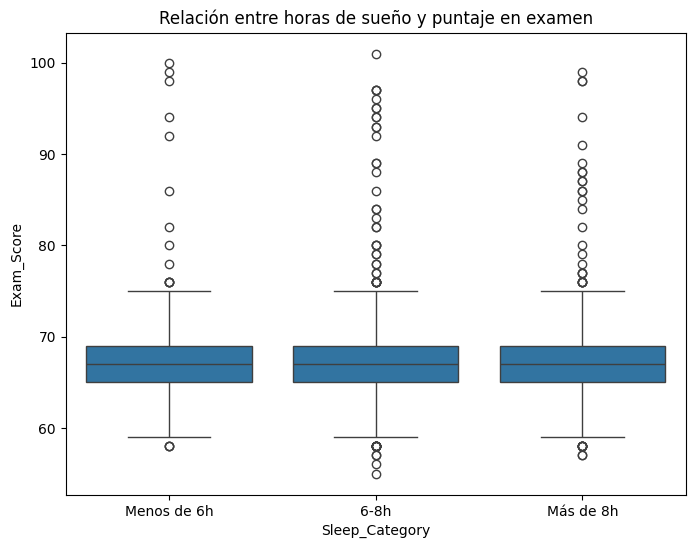

In [34]:


# Crear categorías de sueño
bins = [0, 6, 8, 24]  # Ajusta según el rango de tus datos
labels = ['Menos de 6h', '6-8h', 'Más de 8h']
df['Sleep_Category'] = pd.cut(df['Sleep_Hours'], bins=bins, labels=labels, right=False)

# Boxplot general
plt.figure(figsize=(8,6))
sns.boxplot(x='Sleep_Category', y='Exam_Score', data=df)
plt.title('Relación entre horas de sueño y puntaje en examen')
plt.show()

Aunque la mediana suelen matenerse similar, se podria intuir que entre mas horas de sueño mejor el desempeño

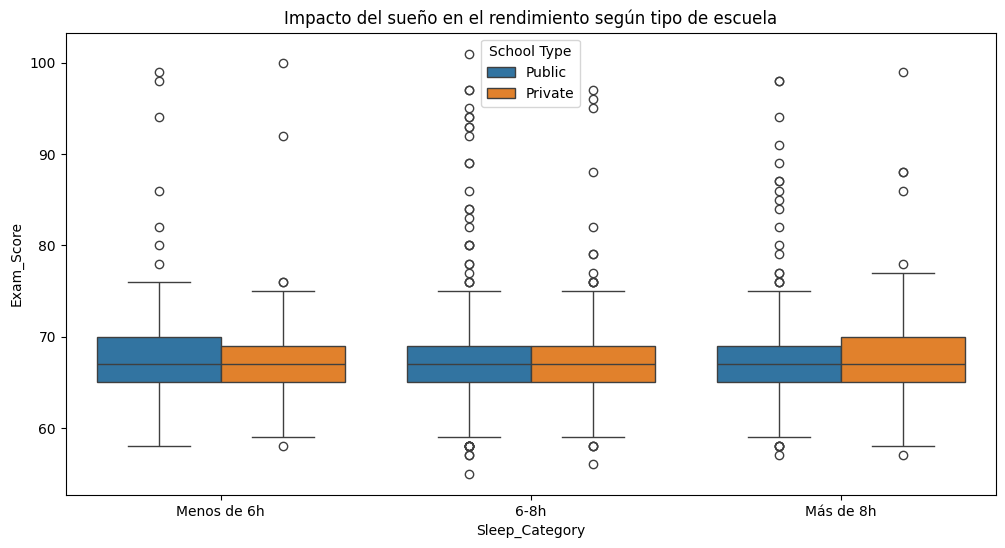

In [35]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Sleep_Category', y='Exam_Score', hue='School_Type', data=df)
plt.title('Impacto del sueño en el rendimiento según tipo de escuela')
plt.legend(title='School Type')
plt.show()

In [36]:
# Calcular medias por categoría de sueño
medias_sueno = df.groupby('Sleep_Category', observed=True)['Exam_Score'].mean()
print(medias_sueno)

# Comparar menos de 6h con 6-8h
if 'Menos de 6h' in medias_sueno.index and '6-8h' in medias_sueno.index:
    caida = (medias_sueno['6-8h'] - medias_sueno['Menos de 6h']) / medias_sueno['6-8h'] * 100
    print(f"Los estudiantes con menos de 6h de sueño tienen un puntaje {caida:.1f}% menor que los que duermen 6-8h.")
else:
    print("Revisa las categorías")

Sleep_Category
Menos de 6h    67.394191
6-8h           67.243009
Más de 8h      67.206639
Name: Exam_Score, dtype: float64
Los estudiantes con menos de 6h de sueño tienen un puntaje -0.2% menor que los que duermen 6-8h.
